# EDA: Предсказание года выпуска песни по тембру

## 1. Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

print("Библиотеки загружены")

Библиотеки загружены


## 2. Источник данных

**Датасет:** YearPredictionMSD (Million Song Dataset)
- Источник: UCI Machine Learning Repository
- Объем: 515,345 треков, 90 признаков
- Целевая переменная: год выпуска (1922-2011)

In [3]:
df = pd.read_csv("year_prediction.csv")
print(f"Данные: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Данные: 515345 строк, 91 столбцов


,label,TimbreAvg1,TimbreAvg2,TimbreAvg3,TimbreAvg4,TimbreAvg5,TimbreAvg6,TimbreAvg7,TimbreAvg8,TimbreAvg9,...,TimbreCovariance69,TimbreCovariance70,TimbreCovariance71,TimbreCovariance72,TimbreCovariance73,TimbreCovariance74,TimbreCovariance75,TimbreCovariance76,TimbreCovariance77,TimbreCovariance78
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


## 3. Описание данных

In [8]:
print(f" Количество записей (песен): {df.shape[0]:,}")
print(f" Количество признаков: {df.shape[1]}")
print(f" Диапазон годов: {df['label'].min()} - {df['label'].max()}")
print(f" Временной период: {df['label'].max() - df['label'].min()} лет")


print(df.dtypes.value_counts().to_string())
print(f"\nВсе признаки числовые")



 Количество записей (песен): 515,345
 Количество признаков: 91
 Диапазон годов: 1922 - 2011
 Временной период: 89 лет
float64    90
int64       1

Все признаки числовые


In [9]:
print(f"Статистика года:")
print(f"   Среднее: {df['label'].mean():.1f}")
print(f"   Медиана: {df['label'].median():.0f}")
print(f"   Стандартное отклонение: {df['label'].std():.1f}")
print(f"   Минимум: {df['label'].min()}")
print(f"   Максимум: {df['label'].max()}")
print(f"   Размах: {df['label'].max() - df['label'].min()} лет")

# Квартили
q1 = df['label'].quantile(0.25)
q3 = df['label'].quantile(0.75)
print(f"   25-й процентиль: {q1:.0f}")
print(f"   50-й процентиль (медиана): {df['label'].median():.0f}")
print(f"   75-й процентиль: {q3:.0f}")
print(f"   Межквартильный размах: {q3 - q1:.0f} лет")


Статистика года:
   Среднее: 1998.4
   Медиана: 2002
   Стандартное отклонение: 10.9
   Минимум: 1922
   Максимум: 2011
   Размах: 89 лет
   25-й процентиль: 1994
   50-й процентиль (медиана): 2002
   75-й процентиль: 2006
   Межквартильный размах: 12 лет


In [12]:
df['decade'] = (df['label'] // 10) * 10
decade_counts = df['decade'].value_counts().sort_index()
for decade, count in decade_counts.items():
    percent = count / len(df) * 100
    bar = "█" * int(percent / 2)
    print(f"   {decade:.0f}-{decade+9}: {count:6,} песен ({percent:5.1f}%) {bar}")

# Категории признаков
timbre_avg_cols = [c for c in df.columns if 'TimbreAvg' in c and 'Covariance' not in c and c != 'decade']
timbre_cov_cols = [c for c in df.columns if 'TimbreCovariance' in c]
engineered_cols = [c for c in df.columns if c not in ['label', 'decade'] + timbre_avg_cols + timbre_cov_cols]

print(f"\n TimbreAvg (средние тембров): {len(timbre_avg_cols)} признаков")
print(f"   Пример: {timbre_avg_cols[:3] if timbre_avg_cols else 'нет'}")

print(f"\nTimbreCovariance (ковариации тембра): {len(timbre_cov_cols)} признаков")
print(f"   Пример: {timbre_cov_cols[:3] if timbre_cov_cols else 'нет'}")

if engineered_cols:
    print(f"\nСозданные признаки (feature engineering): {len(engineered_cols)}")
    print(f"   {engineered_cols}")


   1920-1929:    224 песен (  0.0%) 
   1930-1939:    252 песен (  0.0%) 
   1940-1949:    356 песен (  0.1%) 
   1950-1959:  3,102 песен (  0.6%) 
   1960-1969: 11,739 песен (  2.3%) █
   1970-1979: 24,745 песен (  4.8%) ██
   1980-1989: 41,814 песен (  8.1%) ████
   1990-1999: 124,713 песен ( 24.2%) ████████████
   2000-2009: 299,003 песен ( 58.0%) █████████████████████████████
   2010-2019:  9,397 песен (  1.8%) 

 TimbreAvg (средние тембров): 12 признаков
   Пример: ['TimbreAvg1', 'TimbreAvg2', 'TimbreAvg3']

TimbreCovariance (ковариации тембра): 78 признаков
   Пример: ['TimbreCovariance1', 'TimbreCovariance2', 'TimbreCovariance3']


In [14]:
sample_features = timbre_avg_cols[:5] if timbre_avg_cols else []
if sample_features:
    print("Пример статистики для первых 5 признаков TimbreAvg:")
    print(df[sample_features].describe().round(2))
else:
    print("Нет признаков TimbreAvg для отображения")

missing_total = df.isnull().sum().sum()
duplicates_total = df.duplicated().sum()

print(f"Пропуски (NaN): {missing_total}")
print(f"\nДубликаты строк: {duplicates_total}")

# Проверяем выбросы для целевой переменной
q1_year = df['label'].quantile(0.25)
q3_year = df['label'].quantile(0.75)
iqr_year = q3_year - q1_year
year_outliers = df[(df['label'] < q1_year - 1.5*iqr_year) | (df['label'] > q3_year + 1.5*iqr_year)]
print(f"Выбросы по году: {len(year_outliers)} песен ({len(year_outliers)/len(df)*100:.2f}%)")

# Проверяем для первых признаков
if timbre_avg_cols:
    col = timbre_avg_cols[0]
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]
    print(f"\nВыбросы по {col}: {len(outliers)} строк ({len(outliers)/len(df)*100:.2f}%)")

if 'decade' in df.columns:
    df.drop('decade', axis=1, inplace=True)

correlations = df.corr()['label'].abs().sort_values(ascending=False)
print("\n Топ-5 признаков по корреляции с годом:")
for i, (feature, corr) in enumerate(correlations[1:6].items(), 1):
    print(f"   {i}. {feature:20} : {corr:.4f}")

if 'decade' in df.columns:
    df.drop('decade', axis=1, inplace=True)

Пример статистики для первых 5 признаков TimbreAvg:
       TimbreAvg1  TimbreAvg2  TimbreAvg3  TimbreAvg4  TimbreAvg5
count   515345.00   515345.00   515345.00   515345.00   515345.00
mean        43.39        1.29        8.66        1.16       -6.55
std          6.07       51.58       35.27       16.32       22.86
min          1.75     -337.09     -301.01     -154.18     -181.95
25%         39.95      -26.06      -11.46       -8.49      -20.67
50%         44.26        8.42       10.48       -0.65       -6.01
75%         47.83       36.12       29.76        8.79        7.74
max         61.97      384.07      322.85      335.77      262.07
Пропуски (NaN): 0

Дубликаты строк: 214
Выбросы по году: 29703 песен (5.76%)

Выбросы по TimbreAvg1: 10627 строк (2.06%)

 Топ-5 признаков по корреляции с годом:
   1. TimbreAvg1           : 0.2254
   2. TimbreAvg6           : 0.1874
   3. TimbreAvg3           : 0.1395
   4. TimbreCovariance51   : 0.1263
   5. TimbreCovariance28   : 0.1240


## 4. Feature Engineering

Добавление новых фичей:

In [21]:
timbre_cols = [c for c in df.columns if 'TimbreAvg' in c and 'Covariance' not in c]
print(f"   Обнаружено признаков TimbreAvg: {len(timbre_cols)}")

df['Avg_Mean'] = df[timbre_cols].mean(axis=1)
print(f"   Avg_Mean - среднее арифметическое")

df['Avg_Std'] = df[timbre_cols].std(axis=1)
print(f"   Avg_Std - стандартное отклонение")

df['Avg_Range'] = df[timbre_cols].max(axis=1) - df[timbre_cols].min(axis=1)
print(f"   Avg_Range - размах значений")

df['Avg_Median'] = df[timbre_cols].median(axis=1)
print(f"   Avg_Median - медианное значение")

df['Avg_Sum'] = df[timbre_cols].sum(axis=1)
print(f"   Avg_Sum - сумма значений")

df['Avg_Skew'] = df[timbre_cols].skew(axis=1)
print(f"   Avg_Skew - коэффициент асимметрии")

df['Avg_CV'] = df['Avg_Std'] / (df['Avg_Mean'] + 1e-6)
print(f"   Avg_CV - коэффициент вариации")

cov_cols = [c for c in df.columns if 'TimbreCovariance' in c]
df['Cov_Mean'] = df[cov_cols].mean(axis=1)
print(f"   Cov_Mean - среднее ковариаций")

df['Cov_Std'] = df[cov_cols].std(axis=1)
print(f"   Cov_Std - стандартное отклонение ковариаций")

df['Cov_Sum'] = df[cov_cols].sum(axis=1)
print(f"   Cov_Sum - сумма ковариаций")

diag_indices = list(range(0, min(len(cov_cols), 80), 9))
if diag_indices:
    diag_cols = [cov_cols[i] for i in diag_indices if i < len(cov_cols)]
    df['Cov_Trace'] = df[diag_cols].sum(axis=1)
    print(f"   Cov_Trace - след матрицы")

correlations = df.corr()['label'].abs().sort_values(ascending=False)
top_features = [f for f in correlations.index[1:4] if f not in ['label']]

for feat in top_features[:3]:
    df[f'{feat}_squared'] = df[feat] ** 2
    print(f"  {feat}_squared - квадрат признака")

    if df[feat].min() > 0:
        df[f'{feat}_sqrt'] = np.sqrt(df[feat])
        print(f"  {feat}_sqrt - корень из признака")

   Обнаружено признаков TimbreAvg: 12
   Avg_Mean - среднее арифметическое
   Avg_Std - стандартное отклонение
   Avg_Range - размах значений
   Avg_Median - медианное значение
   Avg_Sum - сумма значений
   Avg_Skew - коэффициент асимметрии
   Avg_CV - коэффициент вариации
   Cov_Mean - среднее ковариаций
   Cov_Std - стандартное отклонение ковариаций
   Cov_Sum - сумма ковариаций
   Cov_Trace - след матрицы
   TimbreAvg1_squared - квадрат признака
   TimbreAvg1_sqrt - корень из признака
   TimbreAvg6_squared - квадрат признака
   TimbreAvg3_squared - квадрат признака


Визуализация распределений и корреляций

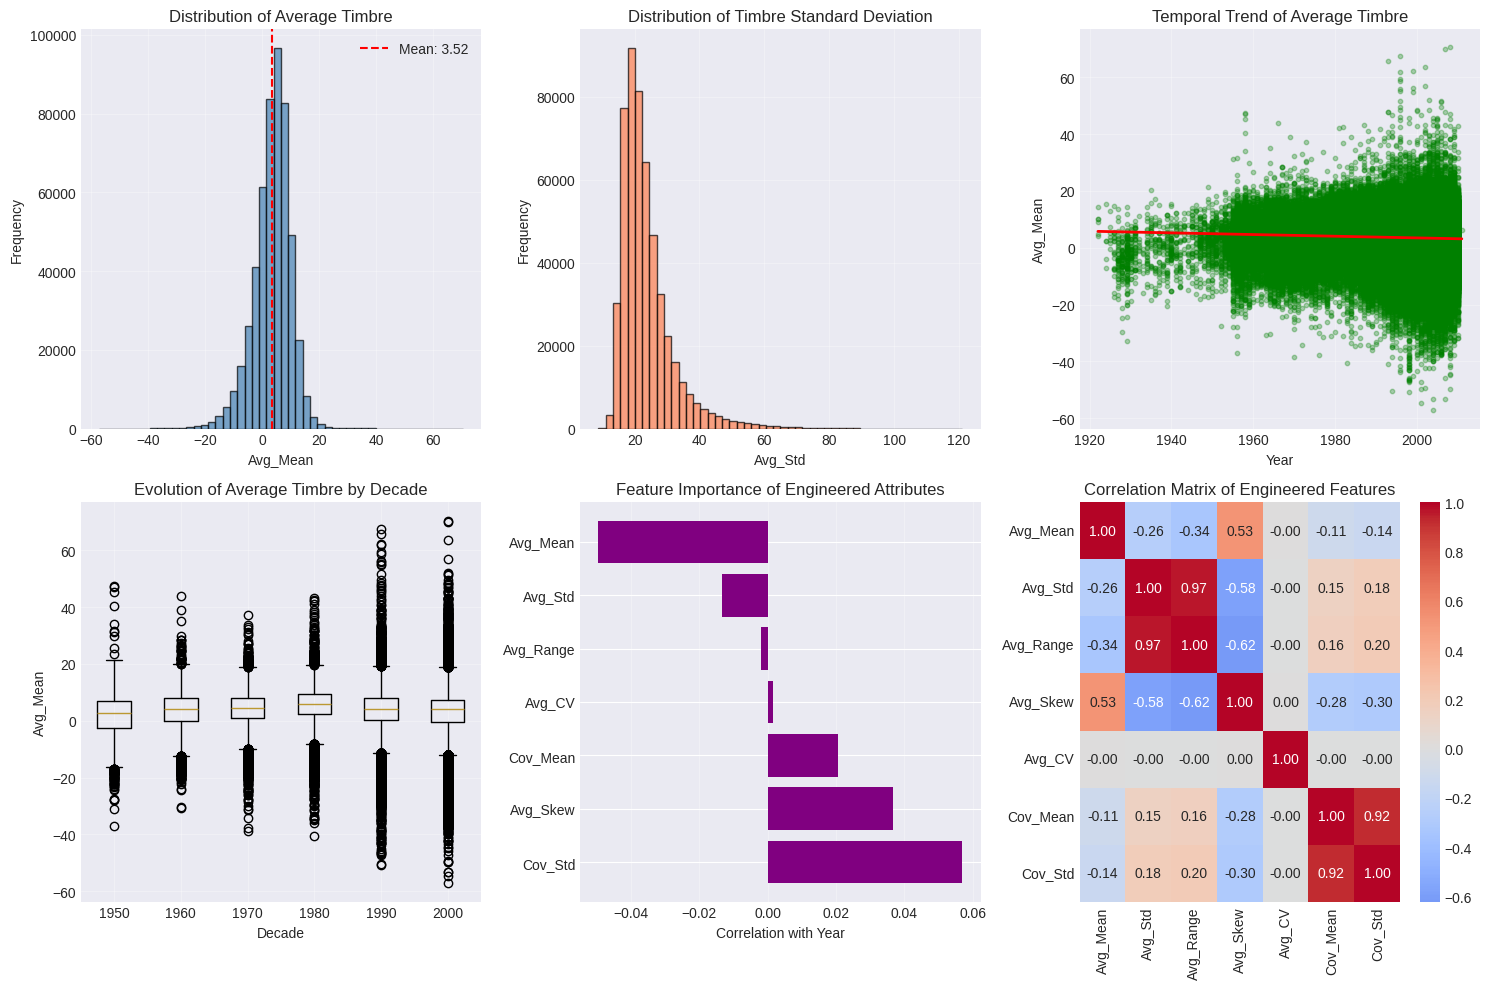

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Распределение Avg_Mean
axes[0, 0].hist(df['Avg_Mean'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Avg_Mean')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Average Timbre')
axes[0, 0].axvline(df['Avg_Mean'].mean(), color='red', linestyle='--',
                   label=f'Mean: {df["Avg_Mean"].mean():.2f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Распределение Avg_Std
axes[0, 1].hist(df['Avg_Std'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Avg_Std')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Timbre Standard Deviation')
axes[0, 1].grid(True, alpha=0.3)

# 3. Зависимость Avg_Mean от года
axes[0, 2].scatter(df['label'], df['Avg_Mean'], alpha=0.3, s=10, color='green')
z = np.polyfit(df['label'], df['Avg_Mean'], 1)
p = np.poly1d(z)
axes[0, 2].plot(df['label'].sort_values(), p(df['label'].sort_values()), 'r-', linewidth=2)
axes[0, 2].set_xlabel('Year')
axes[0, 2].set_ylabel('Avg_Mean')
axes[0, 2].set_title('Temporal Trend of Average Timbre')
axes[0, 2].grid(True, alpha=0.3)


# 4. Boxplot Avg_Mean по десятилетиям
if 'decade' not in df.columns:
    df['decade'] = (df['label'] // 10) * 10

decades = [1950, 1960, 1970, 1980, 1990, 2000]
data_to_plot = [df[df['decade'] == d]['Avg_Mean'].values for d in decades if len(df[df['decade'] == d]) > 0]
axes[1, 0].boxplot(data_to_plot, labels=[str(d) for d in decades if len(df[df['decade'] == d]) > 0])
axes[1, 0].set_xlabel('Decade')
axes[1, 0].set_ylabel('Avg_Mean')
axes[1, 0].set_title('Evolution of Average Timbre by Decade')
axes[1, 0].grid(True, alpha=0.3)

# 5. Корреляция новых признаков с годом
new_features_list = ['Avg_Mean', 'Avg_Std', 'Avg_Range', 'Avg_Skew', 'Avg_CV']
if 'Cov_Mean' in df.columns:
    new_features_list.extend(['Cov_Mean', 'Cov_Std'])
if 'is_modern' in df.columns:
    new_features_list.append('is_modern')

corr_new = df[new_features_list + ['label']].corr()['label'].drop('label').sort_values(ascending=False)
axes[1, 1].barh(range(len(corr_new)), corr_new.values, color='purple')
axes[1, 1].set_yticks(range(len(corr_new)))
axes[1, 1].set_yticklabels(corr_new.index)
axes[1, 1].set_xlabel('Correlation with Year')
axes[1, 1].set_title('Feature Importance of Engineered Attributes')
axes[1, 1].grid(True, alpha=0.3, axis='x')

# 6. Тепловая карта
if len(new_features_list) >= 2:
    corr_matrix = df[new_features_list].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 2])
    axes[1, 2].set_title('Correlation Matrix of Engineered Features')

plt.tight_layout()
plt.show()


Корреляция с целевой переменной новых фичей:

In [31]:
created_features = [
    'Avg_Mean',
    'Avg_Std',
    'Avg_Range',
    'Avg_Median',
    'Avg_Sum',
    'Avg_Skew',
    'Avg_CV',
    'Cov_Mean',
    'Cov_Std',
    'Cov_Sum',
    'Cov_Trace',
    'TimbreAvg1_squared',
    'TimbreAvg1_sqrt',
    'TimbreAvg6_squared',
    'TimbreAvg3_squared'
]

correlation_results = {}
for feature in created_features:
        corr = df[feature].corr(df['label'])
        correlation_results[feature] = corr
sorted_features = sorted(correlation_results.items(), key=lambda x: abs(x[1]), reverse=True)

for feature, corr in sorted_features:
    print(f"{feature:25} : {corr:.6f}")


TimbreAvg1_squared        : 0.236769
TimbreAvg1_sqrt           : 0.217407
TimbreAvg6_squared        : 0.112561
Cov_Trace                 : -0.096895
Avg_Median                : -0.058376
Cov_Std                   : 0.056971
Avg_Sum                   : -0.049530
Avg_Mean                  : -0.049530
TimbreAvg3_squared        : -0.045233
Avg_Skew                  : 0.036618
Cov_Mean                  : 0.020541
Cov_Sum                   : 0.020541
Avg_Std                   : -0.013388
Avg_Range                 : -0.001963
Avg_CV                    : 0.001458


## 5. Визуализации

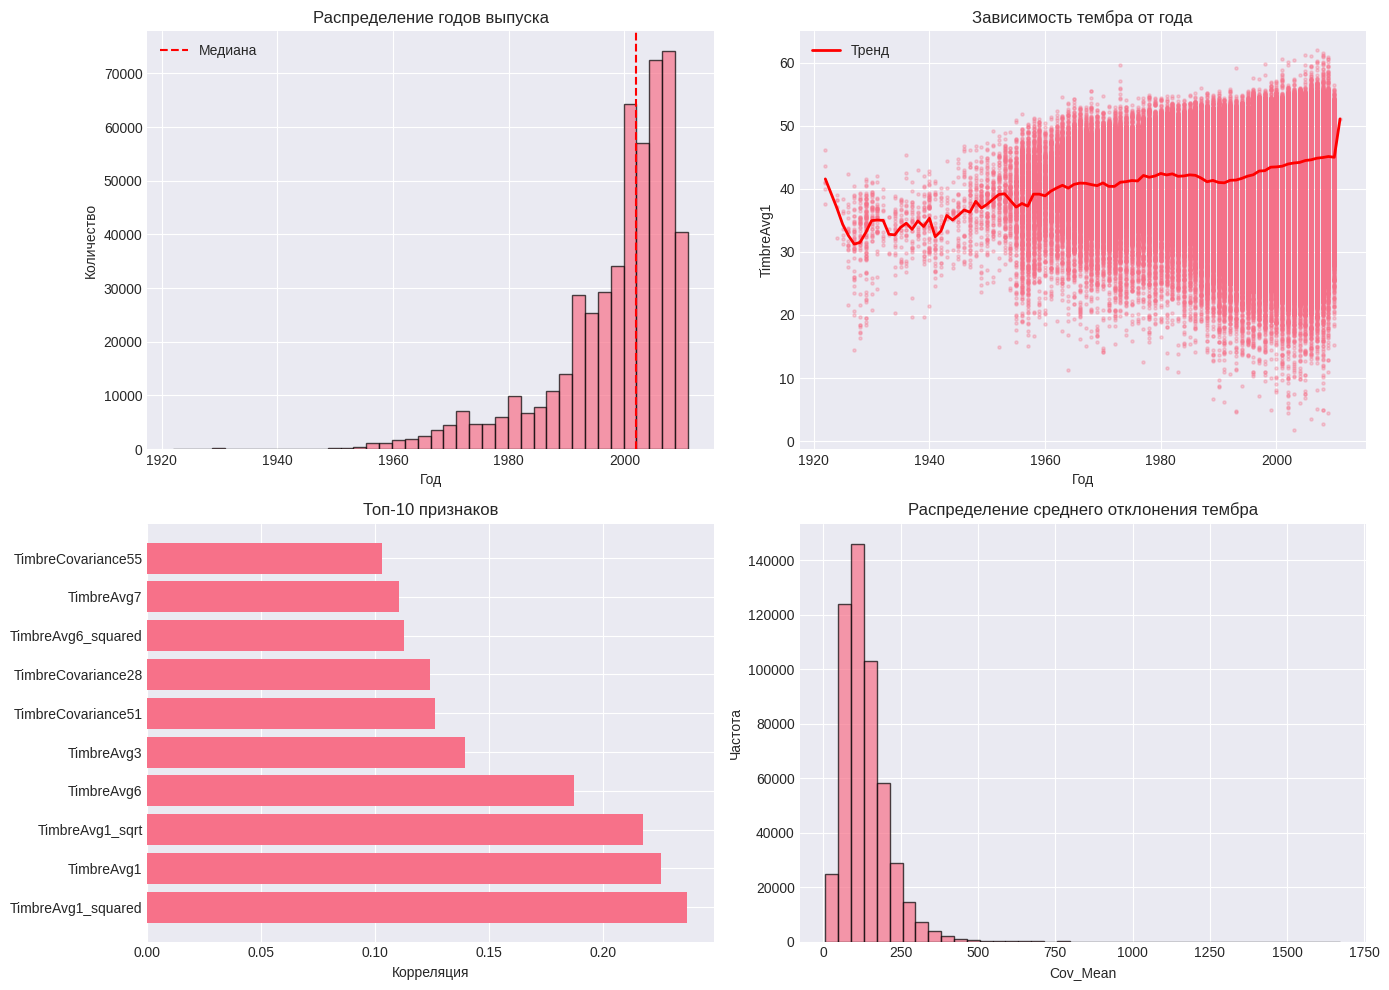

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Распределение годов
axes[0, 0].hist(df['label'], bins=40, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Год')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].set_title('Распределение годов выпуска')
axes[0, 0].axvline(df['label'].median(), color='red', linestyle='--', label='Медиана')
axes[0, 0].legend()

# График 2: Тренд TimbreAvg1
yearly_mean = df.groupby('label')['TimbreAvg1'].mean()
axes[0, 1].scatter(df['label'], df['TimbreAvg1'], alpha=0.3, s=5)
axes[0, 1].plot(yearly_mean.index, yearly_mean.values, 'r-', linewidth=2, label='Тренд')
axes[0, 1].set_xlabel('Год')
axes[0, 1].set_ylabel('TimbreAvg1')
axes[0, 1].set_title('Зависимость тембра от года')
axes[0, 1].legend()

# График 3: Корреляции
corr = df.corr()['label'].abs().sort_values(ascending=False)[2:12]
axes[1, 0].barh(range(len(corr)), corr.values)
axes[1, 0].set_yticks(range(len(corr)))
axes[1, 0].set_yticklabels(corr.index)
axes[1, 0].set_xlabel('Корреляция')
axes[1, 0].set_title('Топ-10 признаков')

# График 4: Распределение Avg_Mean
axes[1, 1].hist(df['Cov_Mean'], bins=40, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Cov_Mean')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].set_title('Распределение среднего отклонения тембра')

plt.tight_layout()
plt.show()

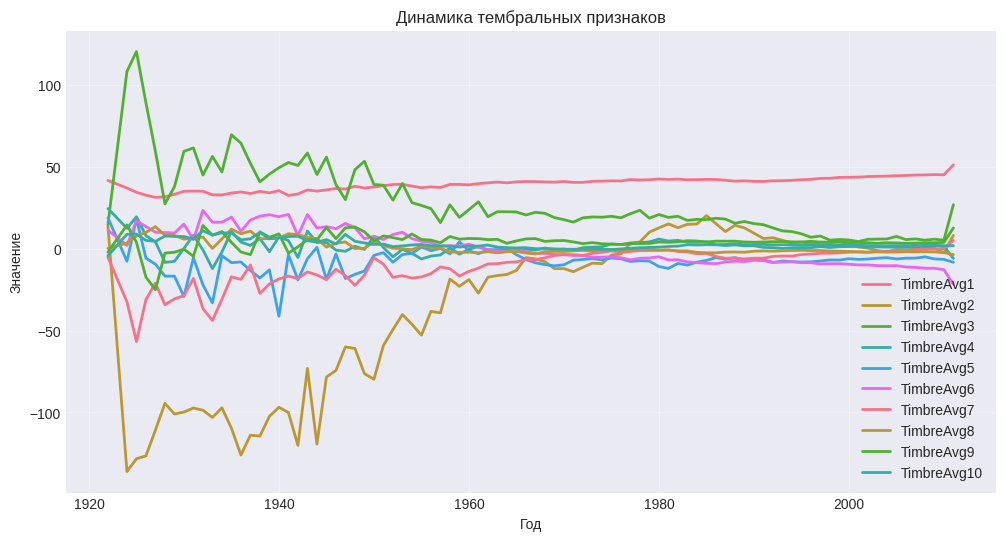

In [41]:
# Динамика признаков
plt.figure(figsize=(12, 6))
for col in timbre_cols[:10]:
    yearly_mean = df.groupby('label')[col].mean()
    plt.plot(yearly_mean.index, yearly_mean.values, label=col, linewidth=2)
plt.xlabel('Год')
plt.ylabel('Значение')
plt.title('Динамика тембральных признаков')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Сплит данных

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('label', axis=1)
y = df['label']

# Разбиваем на train+val и test
X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=pd.cut(y, bins=20)  # стратификация по году
)

# Разбиваем train+val на train и val
val_relative_size = 0.1 / (1 - 0.2)
X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=val_relative_size,
        random_state=42,
        stratify=pd.cut(y_train_val, bins=20)
)

print(f"\nРаспределение данных:")
print(f"   Train: {X_train.shape[0]:,} ({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"   Val:   {X_val.shape[0]:,} ({X_val.shape[0] / len(X) * 100:.1f}%)")
print(f"   Test:  {X_test.shape[0]:,} ({X_test.shape[0] / len(X) * 100:.1f}%)")

print(f"\nДиапазон годов:")
print(f"   Train: {y_train.min():.0f} - {y_train.max():.0f}")
print(f"   Val:   {y_val.min():.0f} - {y_val.max():.0f}")
print(f"   Test:  {y_test.min():.0f} - {y_test.max():.0f}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Распределение данных:
   Train: 360,741 (70.0%)
   Val:   51,535 (10.0%)
   Test:  103,069 (20.0%)

Диапазон годов:
   Train: 1922 - 2010
   Val:   1922 - 2011
   Test:  1924 - 2010


## 7. Метрики качества

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("ОСНОВНАЯ МЕТРИКА: MAE (Mean Absolute Error)")
print("- Интерпретация: ошибка в среднем на X лет")
print("- Преимущество: робастна к выбросам\n")

print("ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ:")
print("- RMSE: штрафует большие ошибки")
print("- R2: доля объясненной дисперсии")

ОСНОВНАЯ МЕТРИКА: MAE (Mean Absolute Error)
- Интерпретация: ошибка в среднем на X лет
- Преимущество: робастна к выбросам

ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ:
- RMSE: штрафует большие ошибки
- R2: доля объясненной дисперсии
